# Phase 2: Topological Profiling & Baselines
This notebook processes the `sample_snowball_500k.json` dataset to establish the 'normal' structure of the sub-sampled citation network.

## Goals
1. **Baseline Metrics**: Compute global clustering coefficient, network density, diameter, and average path length.
2. **Structural Decomposition**: Decompose the graph into its fundamental bow-tie structure (SCC, IN, OUT, Tendrils/Tubes, Disconnected).
3. **Scale-Free Verification**: Plot degree distributions on a log-log scale and use MLE to estimate the degree exponent $\gamma$.
4. **Null Models**: Generate Erdős-Rényi and Barabási-Albert null models with matching parameters for baseline comparisons.



In [3]:
import json
import math
import os
import random
from collections import Counter, deque
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from tqdm.auto import tqdm

try:
    import powerlaw
    HAS_POWERLAW = True
    print("powerlaw package found. MLE scale-free verification will be performed.")
except ImportError:
    HAS_POWERLAW = False
    print("WARNING: powerlaw package not found. Please install it (`pip install powerlaw`) for MLE scale-free verification.")

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

INPUT_FILE = "sample_snowball_500k.json"
OUT_DIR = Path("graph_analysis_outputs")
OUT_DIR.mkdir(exist_ok=True)



/Users/pratyushgupta/Desktop/SI/NS-Project/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


powerlaw package found. MLE scale-free verification will be performed.


## 1. Data Loading & Graph Construction
Load the closed-world citation dataset into a directed graph.


In [4]:
def load_graph_from_sample_json(path: str) -> tuple[nx.DiGraph, list[dict]]:
    print(f"Loading data from {path}...")
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        data = json.load(f)

    if isinstance(data, dict) and "root" in data:
        papers = data["root"]
    else:
        papers = data

    G = nx.DiGraph()
    for paper in papers:
        G.add_node(paper["id"])

    print("Adding edges...")
    for paper in tqdm(papers):
        src = paper["id"]
        for ref in paper.get("references", []):
            if ref in G:
                G.add_edge(src, ref)

    print(f"Graph loaded: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges.")
    return G, papers

G, papers = load_graph_from_sample_json(INPUT_FILE)
# Work with undirected version when strictly required (e.g., path lengths, clustering)
G_undirected = G.to_undirected()



Loading data from sample_snowball_500k.json...
Adding edges...


100%|██████████| 500000/500000 [00:11<00:00, 43636.41it/s] 


Graph loaded: 500,000 nodes, 4,871,544 edges.


## 2. Baseline Metrics
Compute the fundamental properties of the network. Note: For extremely large networks (like our 500k node sample), calculating exact diameter and average path lengths is computational unfeasible ($O(V^3)$ or $O(VE)$). We will approximate these metrics using robust sampling strategies and the double-sweep algorithm on the giant weakly connected component.

**Metrics computed**:
- **Denseness**: Network Density
- **Global Clustering**: Sampled global clustering coefficient (transitivity)
- **Extremes**: Approximate Diameter
- **Distances**: Average Path Length



In [6]:
def compute_baseline_metrics(G, U):
    metrics = {}
    metrics['Network Density'] = nx.density(G)
    
    print("Extracting Giant Weak Component for distance metrics...")
    components = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
    if not components:
        return metrics
        
    Gw_nodes = components[0]
    Uw = U.subgraph(Gw_nodes)
    
    print("Approximating Global Clustering Coefficient (Node Sample)...")
    # Exact transitivity (global clustering) counting 3-cliques is too slow on dense large graphs
    # We approximate average clustering. 
    # Or sample a thousand nodes
    nodes_sample = random.sample(list(Uw.nodes()), min(1000, Uw.number_of_nodes()))
    metrics['Approx Average Clustering'] = nx.average_clustering(Uw, nodes=nodes_sample)
    
    print("Approximating Diameter (Double-Sweep heuristic)...")
    start = nodes_sample[0]
    lengths1 = nx.single_source_shortest_path_length(Uw, start)
    far1 = max(lengths1, key=lengths1.get)
    lengths2 = nx.single_source_shortest_path_length(Uw, far1)
    far2 = max(lengths2, key=lengths2.get)
    metrics['Approx Diameter'] = lengths2[far2]
    
    print("Approximating Average Path Length (Sampled Node Pairs)...")
    path_lengths = []
    # Take short paths from a subset of random nodes to all reachable nodes
    sample_size = 20 # LOWERED FROM 200 TO SAVE TIME
    for n in tqdm(random.sample(list(Uw.nodes()), min(sample_size, Uw.number_of_nodes())), desc="Path Sampling"):
        distances = nx.single_source_shortest_path_length(Uw, n)
        path_lengths.extend(distances.values())
        
    metrics['Approx Average Path Length'] = float(np.mean(path_lengths)) if path_lengths else 0.0
    
    return metrics

baselines = compute_baseline_metrics(G, G_undirected)

print("\n" + "="*50)
print("BASELINE METRICS")
print("="*50)
for k, v in baselines.items():
    print(f"{k}: {v:.6f}" if isinstance(v, float) else f"{k}: {v}")




Extracting Giant Weak Component for distance metrics...
Approximating Global Clustering Coefficient (Node Sample)...
Approximating Diameter (Double-Sweep heuristic)...
Approximating Average Path Length (Sampled Node Pairs)...


Path Sampling: 100%|██████████| 20/20 [07:59<00:00, 23.98s/it]



BASELINE METRICS
Network Density: 0.000019
Approx Average Clustering: 0.265034
Approx Diameter: 6
Approx Average Path Length: 3.921584


## 3. Structural Decomposition (The Bow-Tie Model)
The World Wide Web and citation graphs are known to follow a macroscopic "bow-tie" structure mathematically derived from directed graphs.

Regions:
1. **SCC (Strongly Connected Component)**: The "core" where every paper has a mutual path to each other.
2. **IN**: Papers that can reach the SCC but cannot be reached by it (Early foundation papers or unreferenced old hubs).
3. **OUT**: Papers that can be reached from the SCC but cannot reach it (New papers citing the core, but not yet cited by it).
4. **Tendrils & Tubes**: Nodes that branch off IN but don't reach the SCC, or branch off OUT but aren't reached by the SCC, plus tubes directly from IN to OUT bypassing the SCC.
5. **Disconnected**: Isolated components entirely separate from the Giant Weakly Connected Component (WCC).



Finding Giant Strongly Connected Component (SCC)...
SCC Core found: 12,872 nodes
Computing IN-Component (Reverse BFS from SCC)...
IN-Component size: 387,670
Computing OUT-Component (Forward BFS from SCC)...
OUT-Component size: 18,100
Computing WCC (Weakly Connected Component) to determine Tendrils & Disconnected...
Tendrils/Tubes size: 81,358
Disconnected size: 0

STRUCTURAL DECOMPOSITION (BOW-TIE)
Giant SCC Core      :     12,872 nodes (  2.57%)
IN-Component        :    387,670 nodes ( 77.53%)
OUT-Component       :     18,100 nodes (  3.62%)
Tendrils/Tubes      :     81,358 nodes ( 16.27%)
Disconnected        :          0 nodes (  0.00%)


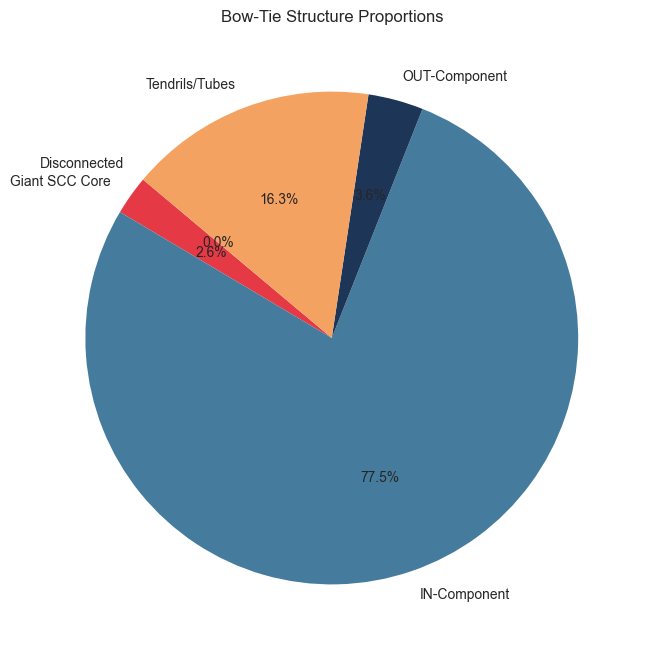

In [7]:
def decompose_bowtie(G):
    print("Finding Giant Strongly Connected Component (SCC)...")
    sccs = list(nx.strongly_connected_components(G))
    if not sccs:
        return {}
        
    giant_scc = max(sccs, key=len)
    SCC = giant_scc
    print(f"SCC Core found: {len(SCC):,} nodes")

    # To find IN: We reverse the graph and do a BFS from the SCC.
    # Everything we can reach (that isn't already in the SCC) is IN.
    print("Computing IN-Component (Reverse BFS from SCC)...")
    G_rev = G.reverse(copy=False)
    in_visited = set()
    queue = deque(SCC)
    for node in SCC:
        in_visited.add(node)
        
    while queue:
        curr = queue.popleft()
        for nbr in G_rev.neighbors(curr):
            if nbr not in in_visited:
                in_visited.add(nbr)
                queue.append(nbr)
    IN_component = in_visited - SCC
    print(f"IN-Component size: {len(IN_component):,}")

    # To find OUT: We use forward BFS from the SCC.
    print("Computing OUT-Component (Forward BFS from SCC)...")
    out_visited = set()
    queue = deque(SCC)
    for node in SCC:
        out_visited.add(node)
        
    while queue:
        curr = queue.popleft()
        for nbr in G.neighbors(curr):
            if nbr not in out_visited:
                out_visited.add(nbr)
                queue.append(nbr)
    OUT_component = out_visited - SCC
    print(f"OUT-Component size: {len(OUT_component):,}")

    # Find the Giant Weak Component 
    print("Computing WCC (Weakly Connected Component) to determine Tendrils & Disconnected...")
    wccs = list(nx.weakly_connected_components(G))
    giant_wcc = max(wccs, key=len)
    
    # Tendrils/Tubes: In the giant WCC, but not in SCC, IN, or OUT
    tendrils_tubes = giant_wcc - SCC - IN_component - OUT_component
    print(f"Tendrils/Tubes size: {len(tendrils_tubes):,}")
    
    # Disconnected: Everything not in the giant WCC
    disconnected = set(G.nodes()) - giant_wcc
    print(f"Disconnected size: {len(disconnected):,}")
    
    return {
        "Giant SCC Core": SCC,
        "IN-Component": IN_component,
        "OUT-Component": OUT_component,
        "Tendrils/Tubes": tendrils_tubes,
        "Disconnected": disconnected
    }

bowtie = decompose_bowtie(G)

# Plot Bow-tie Distribution
labels = list(bowtie.keys())
sizes = [len(bowtie[k]) for k in labels]
total = sum(sizes)

print("\n" + "="*50)
print("STRUCTURAL DECOMPOSITION (BOW-TIE)")
print("="*50)
for label, size in zip(labels, sizes):
    print(f"{label:<20}: {size:>10,} nodes ({size/total*100:6.2f}%)")

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#E63946', '#457B9D', '#1D3557', '#F4A261', '#E9C46A'])
ax.set_title("Bow-Tie Structure Proportions")
plt.savefig(OUT_DIR / "bowtie_structure.png", dpi=200, bbox_inches='tight')
plt.show()



## 4. Scale-Free Verification
A key property of real-world citation networks is the scale-free distribution of their node degrees—both in-degree (citations) and out-degree (references). 

We will:
1. Plot the degree distributions on standard and log-log scales to visualize the long tail.
2. Utilize Maximum Likelihood Estimation (MLE) using the `powerlaw` package to mathematically fit the power law and compute the degree exponent $\gamma$.

*$P(k) \sim k^{-\gamma}$*


Fitting Power-Law distributions via MLE...


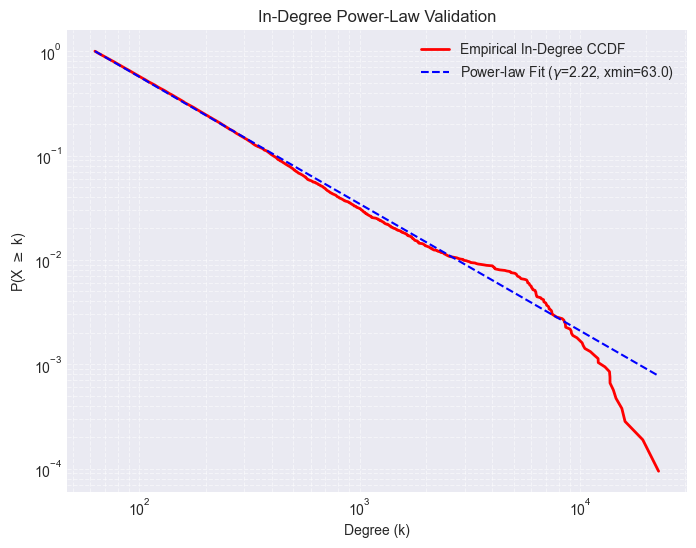

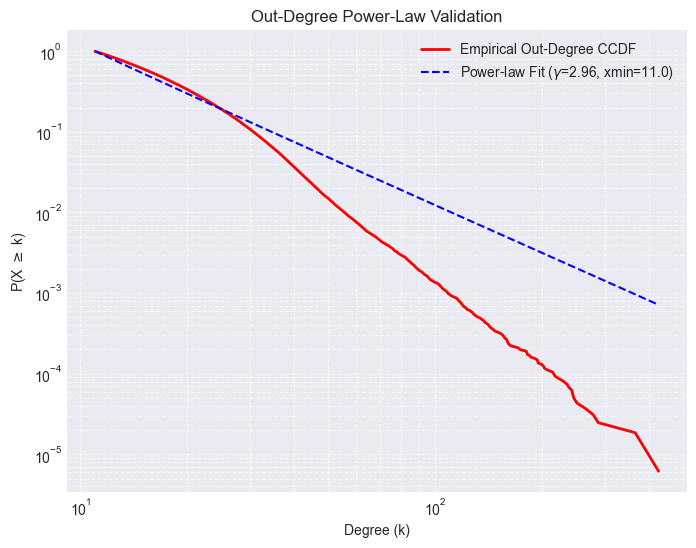

/Users/pratyushgupta/Desktop/SI/NS-Project/venv/lib/python3.9/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution lognormal.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


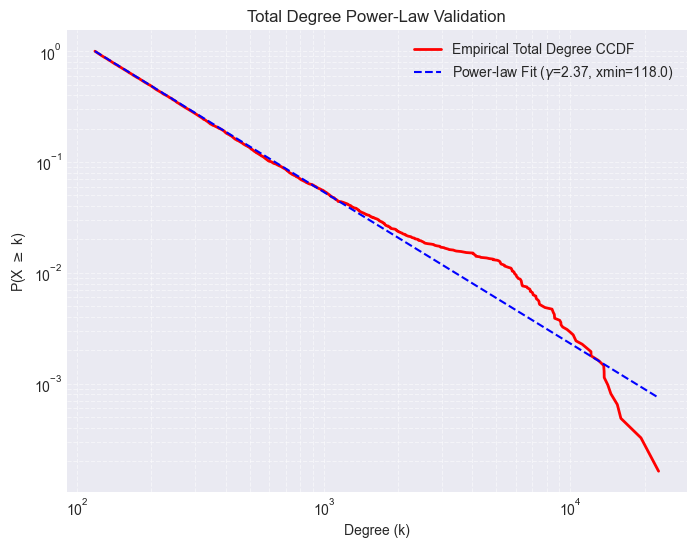


SCALE FREE ESTIMATES (MLE)

--- In-Degree ---
  gamma (alpha): 2.2152099652457027
  xmin: 63.0
  Support for Power-Law vs LogNormal: Weak/Inconclusive

--- Out-Degree ---
  gamma (alpha): 2.956837692972595
  xmin: 11.0
  Support for Power-Law vs LogNormal: Weak/Inconclusive

--- Total Degree ---
  gamma (alpha): 2.36721715665434
  xmin: 118.0
  Support for Power-Law vs LogNormal: Strong


In [8]:
def compute_degree_exponents(G):
    in_degrees = [d for n, d in G.in_degree() if d > 0]
    out_degrees = [d for n, d in G.out_degree() if d > 0]
    total_degrees = [d for n, d in G.degree() if d > 0]
    
    results = {}
    if HAS_POWERLAW:
        print("Fitting Power-Law distributions via MLE...")
        for name, data in [("In-Degree", in_degrees), ("Out-Degree", out_degrees), ("Total Degree", total_degrees)]:
            # Discrete=True is important for degree distributions which are integers
            fit = powerlaw.Fit(data, discrete=True, verbose=False)
            
            # alpha is the terminology powerlaw uses for exponent γ
            gamma = fit.power_law.alpha
            xmin = fit.power_law.xmin
            
            # Compare powerlaw against lognormal (a common competing fat-tailed dist)
            R, p = fit.distribution_compare('power_law', 'lognormal')
            
            results[name] = {
                'gamma (alpha)': gamma,
                'xmin': xmin,
                'Support for Power-Law vs LogNormal': 'Strong' if R > 0 and p < 0.05 else 'Weak/Inconclusive'
            }
            
            # Plot the CCDF and the fit
            plt.figure(figsize=(8, 6))
            fit.plot_ccdf(color='r', linewidth=2, label=f'Empirical {name} CCDF')
            fit.power_law.plot_ccdf(color='b', linestyle='--', label=f'Power-law Fit ($\gamma$={gamma:.2f}, xmin={xmin})')
            plt.title(f"{name} Power-Law Validation")
            plt.xlabel("Degree (k)")
            plt.ylabel("P(X $\geq$ k)")
            plt.legend()
            plt.grid(True, which="both", ls="--", alpha=0.5)
            plt.savefig(OUT_DIR / f"powerlaw_fit_{name.replace(' ', '_').lower()}.png", dpi=200, bbox_inches='tight')
            plt.show()
    else:
        print("Install `powerlaw` for exact MLE estimation. Showing raw empirical distributions instead.")
        
    return results

scale_free_metrics = compute_degree_exponents(G)
if scale_free_metrics:
    print("\n" + "="*50)
    print("SCALE FREE ESTIMATES (MLE)")
    print("="*50)
    for k, v in scale_free_metrics.items():
        print(f"\n--- {k} ---")
        for sub_k, sub_v in v.items():
             print(f"  {sub_k}: {sub_v}")



## 5. Null Models Generation
To contextualize our baseline metrics, we generate analytical Null Models. If our real network exhibits $N$ nodes and $E$ edges:
1. **Erdős-Rényi (Random Graph)**: Edges are generated entirely randomly. This acts as a true baseline for a purely random structure with the exact same density.
   * Probability $p = rac{E}{N 	imes (N - 1)}$
2. **Barabási-Albert (Scale-Free Graph)**: Nodes are added successively with preferential attachment to existing high-degree nodes. This mimics "rich-gets-richer" dynamics.
   * Parameter $m = \lfloor rac{E}{N} 
floor$

*Due to memory and time limits, if $N \sim 500k$, generating exact-sized null models might be expensive in local memory. We will attempt generation; if it fails locally we recommend generating reduced models.*


In [17]:

# Reduced scale generation due to memory constraints
reduced_N = min(N, 50000)
reduced_E = int(E * (reduced_N / N)) if N > 0 else 0

p = reduced_E / (reduced_N * (reduced_N - 1)) if reduced_N > 1 else 0
m = max(1, reduced_E // reduced_N)

print(f"Empirical Network Parameters:\n  N = {N:,}\n  E = {E:,}\n")
print(f"Reduced Null Model Parameters (to save memory):\n  reduced_N = {reduced_N:,}\n  reduced_E = {reduced_E:,}\n  ER Probability (p) = {p:.8e}\n  BA Parameter (m) = {m}")

null_metrics = {}

try:
    print("\nGenerating Erdős-Rényi (ER) random graph... (Fast version)")
    G_er = nx.erdos_renyi_graph(n=reduced_N, p=p, directed=True, seed=42)
    null_metrics['ER Network Density'] = nx.density(G_er)
    null_metrics['ER Approx Global Clustering'] = nx.average_clustering(G_er.to_undirected(), nodes=list(G_er.nodes())[:500])
    print("ER generated successfully.")
except Exception as e:
    print(f"Failed to generate ER Model: {e}")

try:    
    import random
    print("\nGenerating Barabási-Albert (BA) scale-free graph... (Fast version)")
    G_ba = nx.barabasi_albert_graph(n=reduced_N, m=m, seed=42)
    null_metrics['BA Network Density'] = nx.density(G_ba)
    # Using random nodes for clustering to avoid intense hub computations
    nodes_ba = random.sample(list(G_ba.nodes()), min(500, G_ba.number_of_nodes()))
    null_metrics['BA Approx Global Clustering'] = nx.average_clustering(G_ba, nodes=nodes_ba)
    print("BA generated successfully.")
except Exception as e:
    print(f"Failed to generate BA Model: {e}")

print("\n" + "="*50)
print("NULL MODELS COMPARISON")
print("="*50)
print(f"{'Metric':<30} | {'Empirical':<15} | {'ER Model':<15} | {'BA Model':<15}")
print("-" * 85)

empirical_density = baselines.get('Network Density', 0) if 'baselines' in locals() else 0
er_density = null_metrics.get('ER Network Density', 'N/A')
ba_density = null_metrics.get('BA Network Density', 'N/A')

empirical_clustering = baselines.get('Approx Average Clustering', 0) if 'baselines' in locals() else 0
er_clustering = null_metrics.get('ER Approx Global Clustering', 'N/A')
ba_clustering = null_metrics.get('BA Approx Global Clustering', 'N/A')

print(f"{'Density':<30} | {empirical_density:<15.6f} | {er_density if isinstance(er_density, str) else f'{er_density:.6f}':<15} | {ba_density if isinstance(ba_density, str) else f'{ba_density:.6f}':<15}")
print(f"{'Global Clustering':<30} | {empirical_clustering:<15.6f} | {er_clustering if isinstance(er_clustering, str) else f'{er_clustering:.6f}':<15} | {ba_clustering if isinstance(ba_clustering, str) else f'{ba_clustering:.6f}':<15}")




Empirical Network Parameters:
  N = 500,000
  E = 4,871,544

Reduced Null Model Parameters (to save memory):
  reduced_N = 50,000
  reduced_E = 487,154
  ER Probability (p) = 1.94865497e-04
  BA Parameter (m) = 9

Generating Erdős-Rényi (ER) random graph... (Fast version)
ER generated successfully.

Generating Barabási-Albert (BA) scale-free graph... (Fast version)
BA generated successfully.

NULL MODELS COMPARISON
Metric                         | Empirical       | ER Model        | BA Model       
-------------------------------------------------------------------------------------
Density                        | 0.000019        | 0.000195        | 0.000360       
Global Clustering              | 0.265034        | 0.000429        | 0.002532       


In [11]:
# --- EXTRA CELL 1: Detailed Degree Statistics & Top Hubs ---
print("Computing detailed degree statistics...")

def degree_stats(G: nx.DiGraph):
    in_deg = dict(G.in_degree())
    out_deg = dict(G.out_degree())
    total_deg = dict(G.degree())

    in_vals = np.array(list(in_deg.values()))
    out_vals = np.array(list(out_deg.values()))
    total_vals = np.array(list(total_deg.values()))

    isolates = [n for n, d in total_deg.items() if d == 0]

    max_in_node = max(in_deg, key=in_deg.get) if in_deg else None
    max_out_node = max(out_deg, key=out_deg.get) if out_deg else None
    max_total_node = max(total_deg, key=total_deg.get) if total_deg else None

    print(f"Number of Self-Loops: {nx.number_of_selfloops(G)}")
    print(f"Number of Isolates: {len(isolates)} ({(len(isolates) / G.number_of_nodes())*100:.2f}%)")
    print(f"Average In-Degree:  {float(np.mean(in_vals)):.2f}")
    print(f"Average Out-Degree: {float(np.mean(out_vals)):.2f}")
    print(f"Average Total Degree: {float(np.mean(total_vals)):.2f}\n")
    
    print(f"Max In-Degree:    {in_deg[max_in_node]:>6} (Node {max_in_node})")
    print(f"Max Out-Degree:   {out_deg[max_out_node]:>6} (Node {max_out_node})")
    print(f"Max Total Degree: {total_deg[max_total_node]:>6} (Node {max_total_node})")
    
    return in_deg, out_deg, total_deg, isolates

in_deg, out_deg, total_deg, isolates = degree_stats(G)

print("\nTop 5 Nodes by Total Degree (Major Hubs):")
top_total = sorted(total_deg.items(), key=lambda x: x[1], reverse=True)[:5]
for n, d in top_total:
    print(f" Node: {n} | Degree: {d}")


Computing detailed degree statistics...
Number of Self-Loops: 0
Number of Isolates: 0 (0.00%)
Average In-Degree:  9.74
Average Out-Degree: 9.74
Average Total Degree: 19.49

Max In-Degree:     22734 (Node 2151103935)
Max Out-Degree:      426 (Node 1660562555)
Max Total Degree:  22767 (Node 2151103935)

Top 5 Nodes by Total Degree (Major Hubs):
 Node: 2151103935 | Degree: 22767
 Node: 2153635508 | Degree: 19312
 Node: 1639032689 | Degree: 16012
 Node: 2912565176 | Degree: 15485
 Node: 2911964244 | Degree: 14580


In [12]:
# --- EXTRA CELL 2: Reciprocity & Assortativity ---
print("Computing advanced structural correlations...")

def reciprocity_and_assortativity(G: nx.DiGraph):
    try:
        reciprocity = float(nx.reciprocity(G)) if G.number_of_edges() else None
        print(f"Network Reciprocity: {reciprocity:.6f}")
        print(" (Indicates the fraction of citations that are mutual/bi-directional)")
    except Exception as e:
        print("Could not compute reciprocity.")

    try:
        assortativity = float(nx.degree_assortativity_coefficient(G))
        print(f"\nDegree Assortativity Coefficient: {assortativity:.6f}")
        print(" (Negative = hubs connect to low-degree nodes. Positive = hubs connect to hubs)")
    except Exception as e:
        print("Could not compute degree assortativity.")

rel_stats = reciprocity_and_assortativity(G)


Computing advanced structural correlations...
Network Reciprocity: 0.002497
 (Indicates the fraction of citations that are mutual/bi-directional)

Degree Assortativity Coefficient: -0.111507
 (Negative = hubs connect to low-degree nodes. Positive = hubs connect to hubs)


Generating additional metadata visualizations...


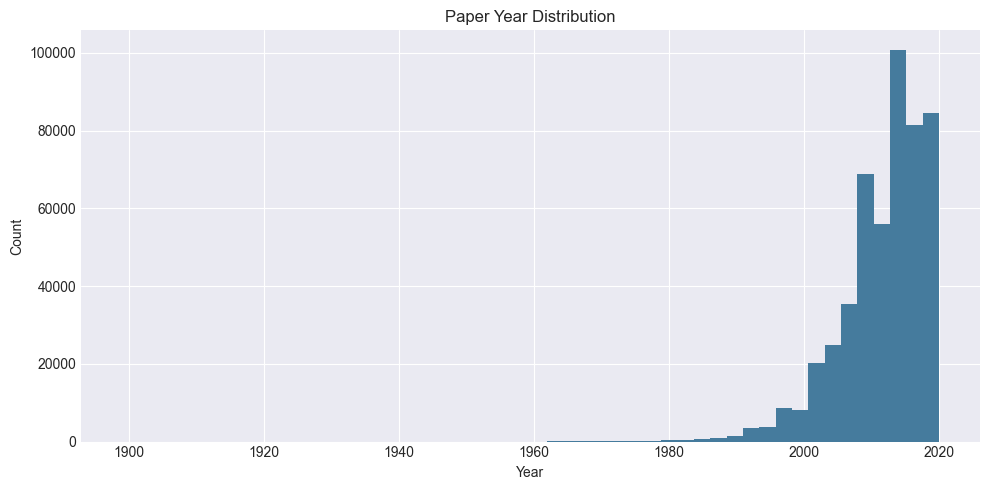

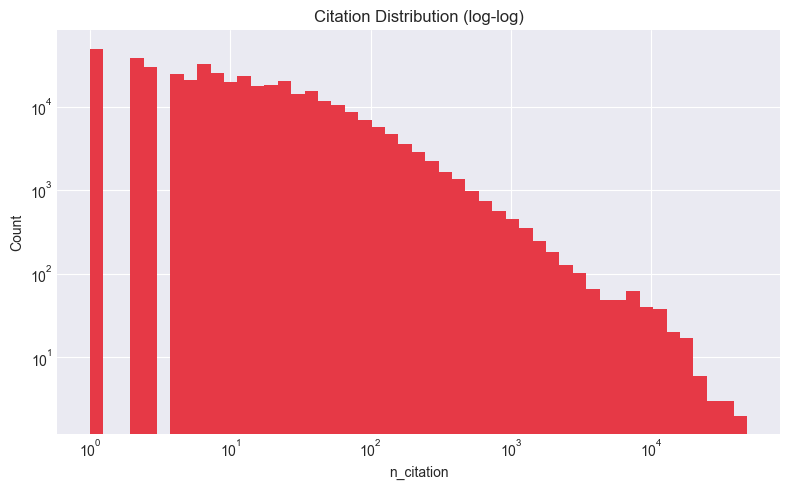

Drawing preview of top hubs network...


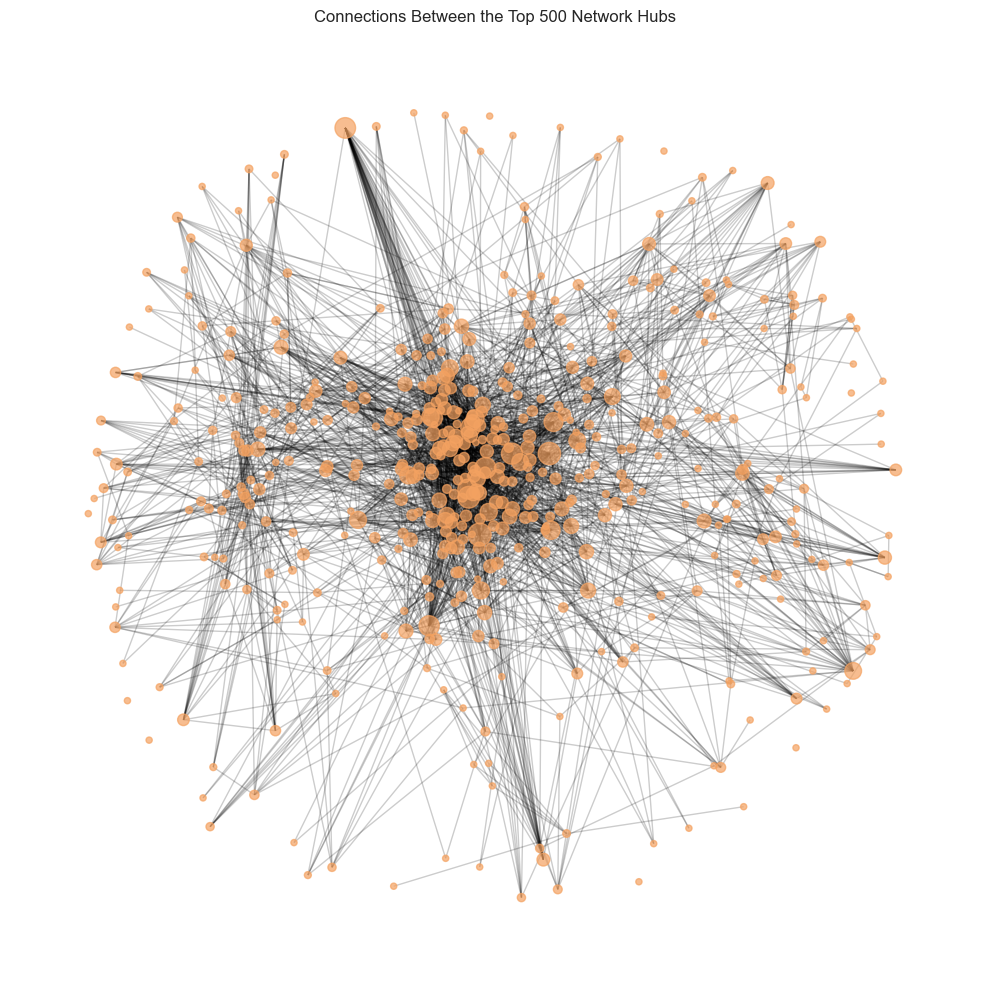

In [19]:
# --- EXTRA CELL 3: Metadata Visualizations & Subset Graph Preview ---
print("Generating additional metadata visualizations...")

def plot_additional_metadata(papers, G):
    # 1. Year Distribution Plot
    years = [int(p.get("year")) for p in papers if isinstance(p.get("year"), (int, float))]
    if years:
        plt.figure(figsize=(10, 5))
        plt.hist(years, bins=50, color='#457B9D')
        plt.xlabel("Year")
        plt.ylabel("Count")
        plt.title("Paper Year Distribution")
        plt.tight_layout()
        plt.savefig(OUT_DIR / "year_distribution.png", dpi=200)
        plt.show()

    # 2. Citation Distribution Plot (log-log)
    cites = np.array([p.get("n_citation") for p in papers if isinstance(p.get("n_citation"), (int, float)) and p.get("n_citation") > 0])
    if len(cites) > 0:
        plt.figure(figsize=(8, 5))
        bins = np.logspace(np.log10(max(1, cites.min())), np.log10(cites.max()), 50)
        plt.hist(cites, bins=bins, color='#E63946')
        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel("n_citation")
        plt.ylabel("Count")
        plt.title("Citation Distribution (log-log)")
        plt.tight_layout()
        plt.savefig(OUT_DIR / "n_citation_distribution.png", dpi=200)
        plt.show()

    # 3. Small Graph Preview (Heavy Hubs)
    # We must extract the giant weakly connected component for a good visual
    wccs = list(nx.weakly_connected_components(G))
    if wccs:
        giant_wcc = max(wccs, key=len)
        Gw = G.subgraph(giant_wcc).copy()
        
        print("Drawing preview of top hubs network...")
        top_nodes = sorted(Gw.degree, key=lambda x: x[1], reverse=True)[:500]
        keep = [n for n, _ in top_nodes]
        H = Gw.subgraph(keep).copy()

        plt.figure(figsize=(10, 10))
        pos = nx.spring_layout(H, seed=42, k=0.15)
        node_sizes = [max(20, 5 * H.degree(n)) for n in H.nodes()]
        nx.draw_networkx_nodes(H, pos, node_size=node_sizes, alpha=0.7, node_color='#F4A261')
        nx.draw_networkx_edges(H, pos, alpha=0.2, arrows=False)
        plt.title("Connections Between the Top 500 Network Hubs")
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(OUT_DIR / "graph_preview_hubs.png", dpi=200)
        plt.show()

plot_additional_metadata(papers, G)


Generating Advanced Network Visualizations...
1. Generating In-Degree vs Out-Degree Density (Hexbin) Plot...


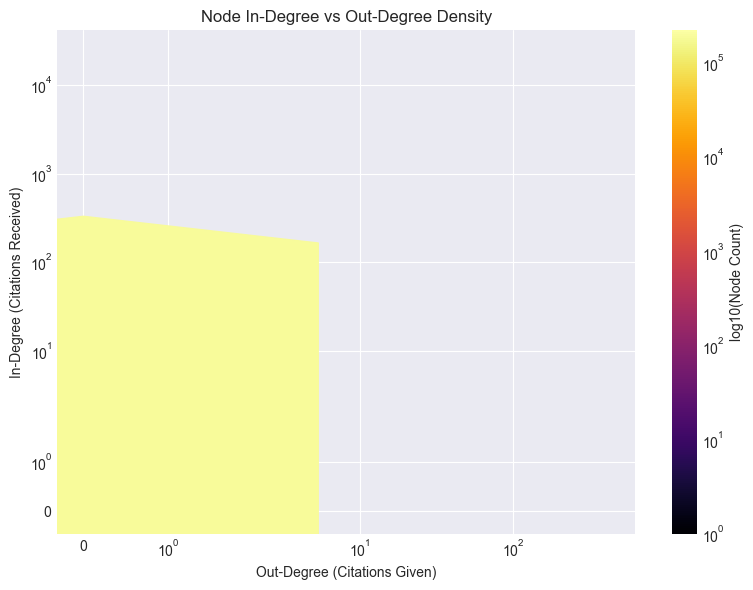

3. Generating Degree Correlation (K_nn vs K) Scatter Plot...


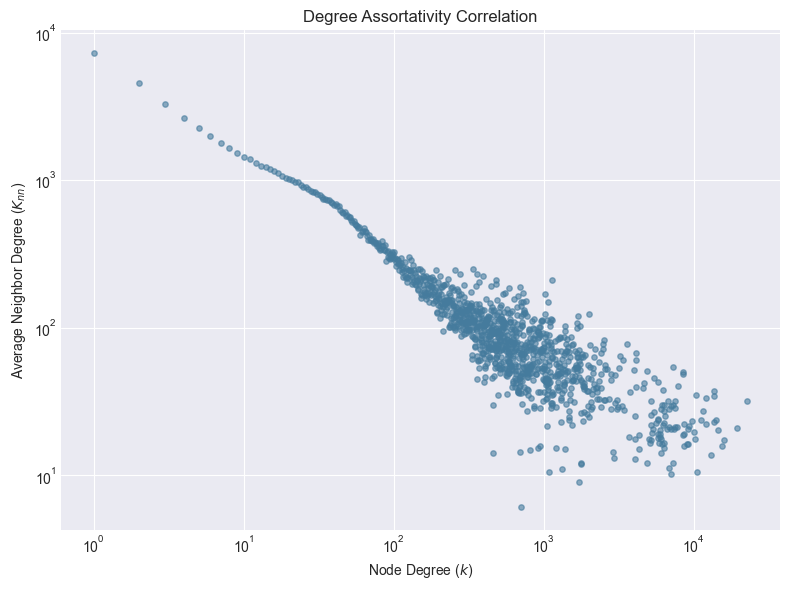

4. Fitting Missing Scale-Free Models for In-Degree and Out-Degree...
   -> Fitting in-degree (Please wait momentarily)...


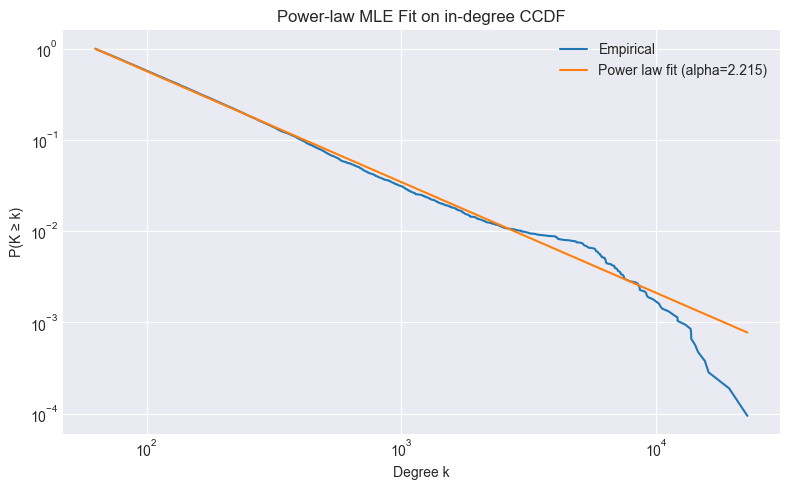

   -> Fitting out-degree (Please wait momentarily)...


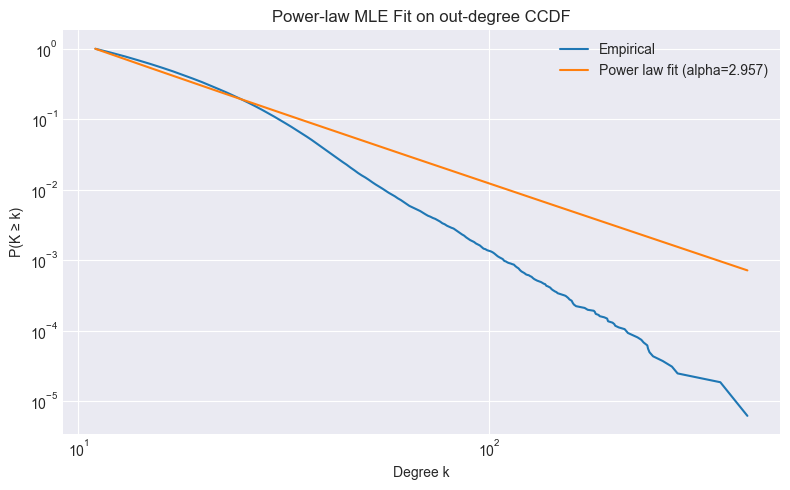

Saved all new and missing plots successfully in target directory!


In [22]:
# --- EXTRA CELL 4: Advanced Network Analytics & Missing Power-Law Fits ---
print("Generating Advanced Network Visualizations...")

def plot_in_vs_out_degree_hexbin(G):
    print("1. Generating In-Degree vs Out-Degree Density (Hexbin) Plot...")
    in_deg = [d for n, d in G.in_degree()]
    out_deg = [d for n, d in G.out_degree()]
    
    plt.figure(figsize=(8, 6))
    plt.hexbin(out_deg, in_deg, gridsize=40, cmap='inferno', bins='log', mincnt=1)
    cb = plt.colorbar(label='log10(Node Count)')
    plt.xscale('symlog')
    plt.yscale('symlog')
    plt.xlabel('Out-Degree (Citations Given)')
    plt.ylabel('In-Degree (Citations Received)')
    plt.title('Node In-Degree vs Out-Degree Density')
    plt.tight_layout()
    plt.savefig(OUT_DIR / "in_vs_out_degree_hexbin.png", dpi=200)
    plt.show()


def plot_knn_degree_correlation(G):
    print("3. Generating Degree Correlation (K_nn vs K) Scatter Plot...")
    try:
        U = G.to_undirected()
        knn = nx.average_neighbor_degree(U)
        degrees = dict(U.degree())
        
        deg_to_knn = {}
        for n, d in degrees.items():
            if d > 0:
                if d not in deg_to_knn:
                    deg_to_knn[d] = []
                deg_to_knn[d].append(knn[n])
        
        x = sorted(deg_to_knn.keys())
        y = [np.mean(deg_to_knn[k]) for k in x]
        
        plt.figure(figsize=(8, 6))
        plt.scatter(x, y, alpha=0.6, color='#457B9D', s=15)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Node Degree ($k$)')
        plt.ylabel('Average Neighbor Degree ($K_{nn}$)')
        plt.title('Degree Assortativity Correlation')
        plt.tight_layout()
        plt.savefig(OUT_DIR / "degree_correlation_knn.png", dpi=200)
        plt.show()
    except Exception as e:
        print(f"Skipping Degree Correlation plot: {e}")

def fit_missing_scale_free_models(G):
    print("4. Fitting Missing Scale-Free Models for In-Degree and Out-Degree...")
    import powerlaw
    
    in_deg = dict(G.in_degree())
    out_deg = dict(G.out_degree())
    
    deg_sets = {
        "in-degree": np.array(list(in_deg.values())),
        "out-degree": np.array(list(out_deg.values()))
    }
    
    for name, values in deg_sets.items():
        values = values[values > 0]
        if len(values) > 0:
            print(f"   -> Fitting {name} (Please wait momentarily)...")
            fit = powerlaw.Fit(values, discrete=True, verbose=False)
            alpha = float(fit.power_law.alpha)
            
            plt.figure(figsize=(8, 5))
            fit.plot_ccdf(label="Empirical")
            fit.power_law.plot_ccdf(label=f"Power law fit (alpha={alpha:.3f})")
            plt.xlabel("Degree k")
            plt.ylabel("P(K ≥ k)")
            plt.title(f"Power-law MLE Fit on {name} CCDF")
            plt.legend()
            plt.tight_layout()
            plt.savefig(OUT_DIR / f"powerlaw_fit_{name}.png", dpi=200)
            plt.show()

# --- Execution ---
plot_in_vs_out_degree_hexbin(G)
plot_knn_degree_correlation(G)

# You will need your Graph G loaded. If 'HAS_POWERLAW' is installed, this will run:
try:
    import powerlaw
    fit_missing_scale_free_models(G)
except ImportError:
    print("Cannot fit missing models: 'powerlaw' library is not installed.")

print("Saved all new and missing plots successfully in target directory!")
